<div align = "right">
27 / 05 / 26
<div style = "height: 20px;"></div>
<span style = "color:orange"> <strong>Reconocimiento de Patrones </strong></span>
<style>div[align = "right"]{font-family: 'Montserrat', sans-serif;}</style></div>

<h1 style = "color: orange"><strong> Práctica 5: Agrupamiento y clasificación</strong></h1>

In [1]:
import numpy as np
import pandas as pd
import cv2
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Subset
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import normalize

## **Implementación de BoW**

#### 1a. Descarga de dataset

Seleccioné el conjunto de datos ``airplane``. 

In [2]:
transform = transforms.Compose([
    transforms.Resize(128, interpolation = transforms.InterpolationMode.LANCZOS),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Descarga
dataset = torchvision.datasets.CIFAR10(
    root = './data',
    train = True,
    download = True,
    transform = transform
)

# Filtrar la clase airplane
airplane_indices = [i for i, label in enumerate(dataset.targets) if label == 0]
airplane_dataset = Subset(dataset, airplane_indices)

print(f'Total imágenes de airplane: {len(airplane_dataset)}')

loader = DataLoader(airplane_dataset, batch_size = 32, shuffle = True)

Total imágenes de airplane: 5000


In [3]:
images, labels = next(iter(loader))
print(f"Shape del batch: {images.shape}") 
print(f'Todas son airplane (0): {labels.unique()}')

Shape del batch: torch.Size([32, 3, 128, 128])
Todas son airplane (0): tensor([0])


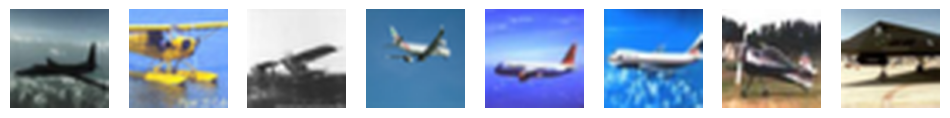

In [4]:
fig, axes = plt.subplots(1, 8, figsize = (12, 2))

for i, ax in enumerate(axes):

    img = images[i].permute(1, 2, 0) * 0.5 + 0.5
    ax.imshow(img.numpy(), interpolation = 'bilinear')
    ax.axis('off')
plt.show()

#### 1b. Descriptores SIFT

Imágenes cargadas: (5000, 128, 128, 3)
Total de descriptores SIFT extraídos: (178172, 128)


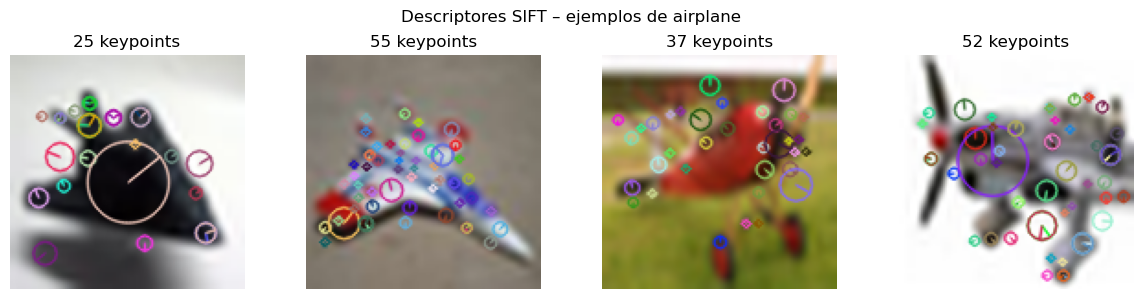

In [ ]:
# Cargar todas las imágenes como arrays numpy uint8 (para OpenCV)
# Se usa el dataset SIN normalizar para que SIFT funcione correctamente
transform_raw = transforms.Compose([
    transforms.Resize(128, interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.ToTensor()
])

dataset_raw = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=transform_raw
)
airplane_indices_raw = [i for i, label in enumerate(dataset_raw.targets) if label == 0]
airplane_dataset_raw = Subset(dataset_raw, airplane_indices_raw)

loader_raw = DataLoader(airplane_dataset_raw, batch_size=len(airplane_dataset_raw), shuffle=False)
all_images_tensor, all_labels_tensor = next(iter(loader_raw))

# Convertir a numpy uint8: (N, H, W, C)
all_images_np = (all_images_tensor.permute(0, 2, 3, 1).numpy() * 255).astype(np.uint8)

print(f"Imágenes cargadas: {all_images_np.shape}")

# Extraer descriptores SIFT de todas las imágenes
sift = cv2.SIFT_create()
all_descriptors = []  # lista de arrays de descriptores por imagen
descriptor_list = []  # lista plana para K-means

for img_bgr in all_images_np:
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_RGB2GRAY)
    kp, desc = sift.detectAndCompute(gray, None)
    if desc is not None:
        all_descriptors.append(desc)
        descriptor_list.extend(desc)
    else:
        all_descriptors.append(np.zeros((1, 128), dtype=np.float32))

descriptor_array = np.array(descriptor_list, dtype=np.float32)
print(f"Total de descriptores SIFT extraídos: {descriptor_array.shape}")

# Visualizar keypoints en 4 imágenes de ejemplo
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    gray = cv2.cvtColor(all_images_np[i], cv2.COLOR_RGB2GRAY)
    kp, _ = sift.detectAndCompute(gray, None)
    img_kp = cv2.drawKeypoints(all_images_np[i], kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    ax.imshow(img_kp)
    ax.set_title(f'{len(kp)} keypoints')
    ax.axis('off')
plt.suptitle('Descriptores SIFT - ejemplos de airplane')
plt.tight_layout()
plt.show()

#### 1c. $k$-means con $k$ clusters para obtener el vocabulario

In [6]:
# Vocabulario visual con k = 100 palabras (valor base para la sección 1)
K = 100

print(f"Entrenando K-Means con k = {K} sobre {descriptor_array.shape[0]} descriptores.")
kmeans = KMeans(n_clusters = K, random_state = 43, n_init = 10)
kmeans.fit(descriptor_array)

Entrenando K-Means con k = 100 sobre 178172 descriptores...
Vocabulario visual construido.


#### 1d. Construir histogramas de palabras (mostrar 5)

Dimensiones de la matriz de histogramas: (5000, 100)


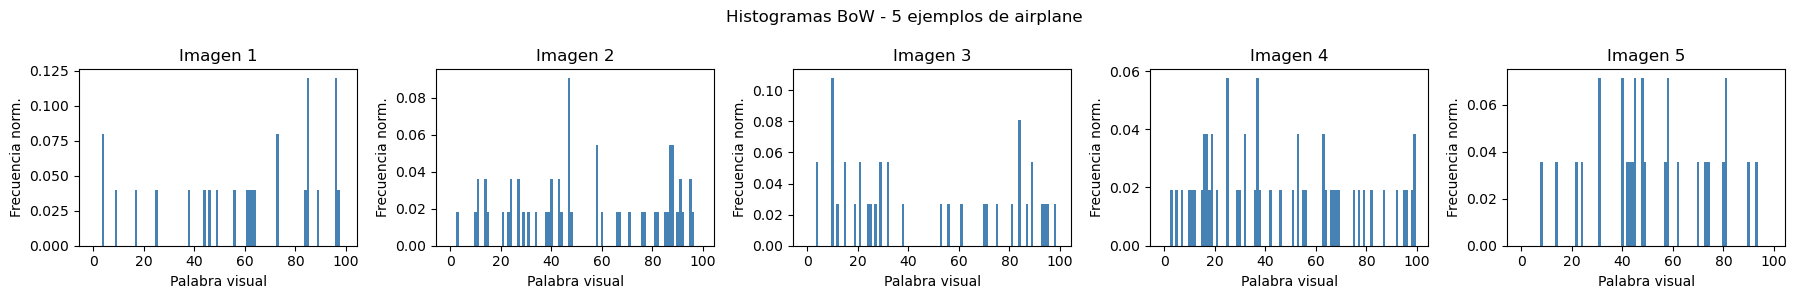

In [7]:
def build_histogram(descriptors, kmeans_model, k):
    """Construye y normaliza el histograma BoW para una imagen."""
    hist = np.zeros(k)
    if descriptors is not None and len(descriptors) > 0:
        words = kmeans_model.predict(descriptors)
        for w in words:
            hist[w] += 1
    # Normalización L1
    if hist.sum() > 0:
        hist = hist / hist.sum()
    return hist

# Construir histograma para cada imagen
histograms = np.array([build_histogram(desc, kmeans, K) for desc in all_descriptors])

print(f"Dimensiones de la matriz de histogramas: {histograms.shape}")

# Mostrar 5 histogramas
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for i, ax in enumerate(axes):
    
    ax.bar(range(K), histograms[i], color='steelblue', width=1.0)
    ax.set_title(f'Imagen {i+1}')
    ax.set_xlabel('Palabra visual')
    ax.set_ylabel('Frecuencia norm.')

plt.suptitle('Histogramas BoW - 5 ejemplos de airplane')
plt.tight_layout()
plt.show()

#### 1e. Dividir el conjunto de entrenamiento y prueba en 80-20.

In [8]:
y = np.zeros(len(histograms), dtype=int)  # todas son clase 0 (airplane)

X_train, X_test, y_train, y_test = train_test_split(histograms, y, test_size=0.2, random_state=43, stratify=y)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")

Entrenamiento: 4000 muestras
Prueba: 1000 muestras


#### 1f. Entrenar un ``SVM`` lineal con los histogramas de entrenamiento usando grid search para los hiperparámetros.

In [9]:
# Nota: con una sola clase el problema de clasificación binaria no es posible.
# Por eso se usa todo CIFAR-10 con las 10 clases para una demostración más completa.
# Se re-extraen descriptores para las 10 clases (submuestra de 500 imágenes por clase).

N_PER_CLASS = 500
K_BASE = 100

dataset_10 = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_raw)

# Submuestra balanceada
indices_10 = []
targets = np.array(dataset_10.targets)
for c in range(10):
    
    idx_c = np.where(targets == c)[0]
    np.random.seed(42)
    chosen = np.random.choice(idx_c, N_PER_CLASS, replace=False)
    indices_10.extend(chosen.tolist())

subset_10 = Subset(dataset_10, indices_10)
loader_10 = DataLoader(subset_10, batch_size=len(indices_10), shuffle=False)
imgs_10_t, labels_10_t = next(iter(loader_10))
imgs_10_np = (imgs_10_t.permute(0, 2, 3, 1).numpy() * 255).astype(np.uint8)
labels_10 = labels_10_t.numpy()

# Extraer SIFT
desc_10_per_img = []
desc_10_all = []
sift2 = cv2.SIFT_create()
for img_rgb in imgs_10_np:
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    _, desc = sift2.detectAndCompute(gray, None)
    if desc is not None:
        desc_10_per_img.append(desc)
        desc_10_all.extend(desc)
    else:
        desc_10_per_img.append(np.zeros((1, 128), dtype=np.float32))

desc_10_arr = np.array(desc_10_all, dtype=np.float32)
print(f"Total descriptores (10 clases): {desc_10_arr.shape}")

# Vocabulario
print(f"Entrenando K-Means k={K_BASE}...")
km_base = KMeans(n_clusters=K_BASE, random_state=42, n_init=10)
km_base.fit(desc_10_arr)

# Histogramas
hists_10 = np.array([build_histogram(d, km_base, K_BASE) for d in desc_10_per_img])

# Split 80-20
X_tr, X_te, y_tr, y_te = train_test_split(
    hists_10, labels_10, test_size=0.2, random_state=42, stratify=labels_10
)
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

# Grid Search SVM lineal
param_grid = {'C': [0.01, 0.1, 1, 10]}
svm_base = SVC(kernel='linear', random_state=42)
grid_svm = GridSearchCV(svm_base, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_svm.fit(X_tr, y_tr)

print(f"\nMejor C: {grid_svm.best_params_}")
print(f"Mejor accuracy en CV: {grid_svm.best_score_:.4f}")

Total descriptores (10 clases): (245210, 128)
Entrenando K-Means k=100...
Train: (4000, 100), Test: (1000, 100)
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Mejor C: {'C': 10}
Mejor accuracy en CV: 0.2828


#### 1g. Predecir las etiquetas del conjunto de prueba y calcular la exactitud.

In [10]:
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_te)

acc_svm = accuracy_score(y_te, y_pred_svm)
print(f"Exactitud SVM lineal (k=100): {acc_svm:.4f} ({acc_svm*100:.2f}%)")

Exactitud SVM lineal (k=100): 0.2810 (28.10%)


#### 1h. Matriz de confusión.

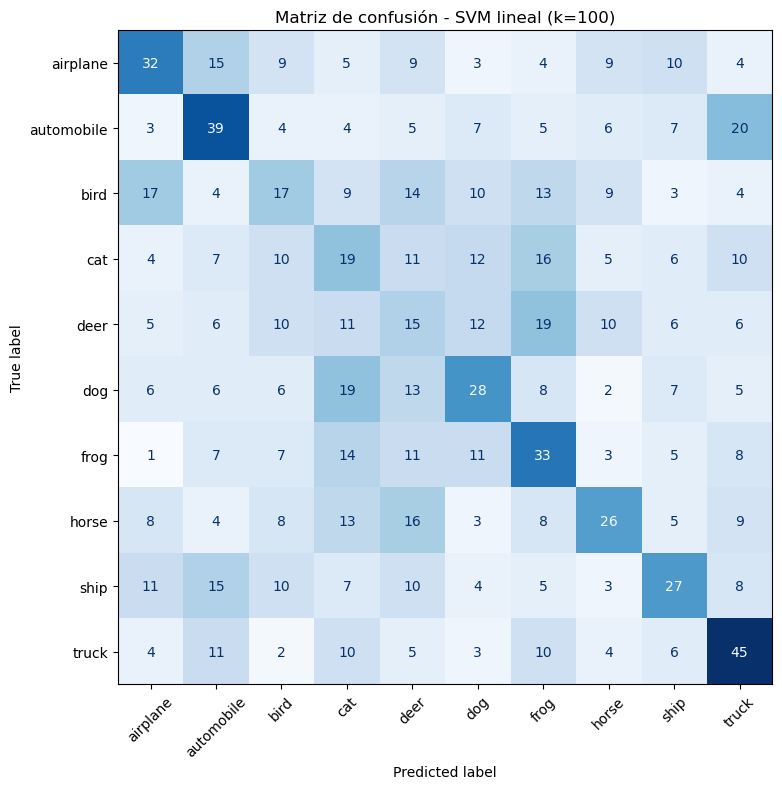

In [11]:
clases = ['airplane','automobile','bird','cat','deer',
          'dog','frog','horse','ship','truck']

cm = confusion_matrix(y_te, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title(f'Matriz de confusión - SVM lineal (k={K_BASE})')
plt.tight_layout()
plt.show()

---
### 2. Evaluación y comparación

#### 2a. Variar las palabras visuales $(k = 50, 200, 500)$


--- k = 50 ---
Accuracy: 0.2570

--- k = 200 ---
Accuracy: 0.2420

--- k = 500 ---
Accuracy: 0.2200


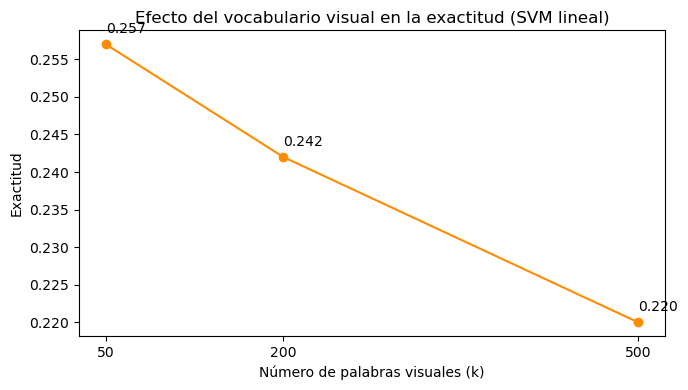

In [12]:
resultados_k = {}

for k_val in [50, 200, 500]:
    print(f"\n--- k = {k_val} ---")
    km_k = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    km_k.fit(desc_10_arr)
    
    hists_k = np.array([build_histogram(d, km_k, k_val) for d in desc_10_per_img])
    
    X_tr_k, X_te_k, y_tr_k, y_te_k = train_test_split(hists_k, labels_10, test_size=0.2, 
                                                      random_state=43, stratify=labels_10)
    
    svm_k = SVC(kernel='linear', C=1.0, random_state=42)
    svm_k.fit(X_tr_k, y_tr_k)
    acc_k = accuracy_score(y_te_k, svm_k.predict(X_te_k))
    resultados_k[k_val] = acc_k
    print(f"Accuracy: {acc_k:.4f}")

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(resultados_k.keys()), list(resultados_k.values()), 'o-', color='darkorange')
ax.set_xlabel('Número de palabras visuales (k)')
ax.set_ylabel('Exactitud')
ax.set_title('Efecto del vocabulario visual en la exactitud (SVM lineal)')
ax.set_xticks([50, 200, 500])
for k_v, a_v in resultados_k.items():
    
    ax.annotate(f'{a_v:.3f}', (k_v, a_v), textcoords='offset points', xytext=(0, 8))

plt.tight_layout()
plt.show()

#### 2b. Cambiar la ``SVM`` por un Random Forest

Fitting 3 folds for each of 4 candidates, totalling 12 fits

Mejores hiperparámetros RF: {'max_depth': None, 'n_estimators': 200}
Exactitud Random Forest (k=100): 0.2730 (27.30%)
Exactitud SVM lineal    (k=100): 0.2810 (28.10%)


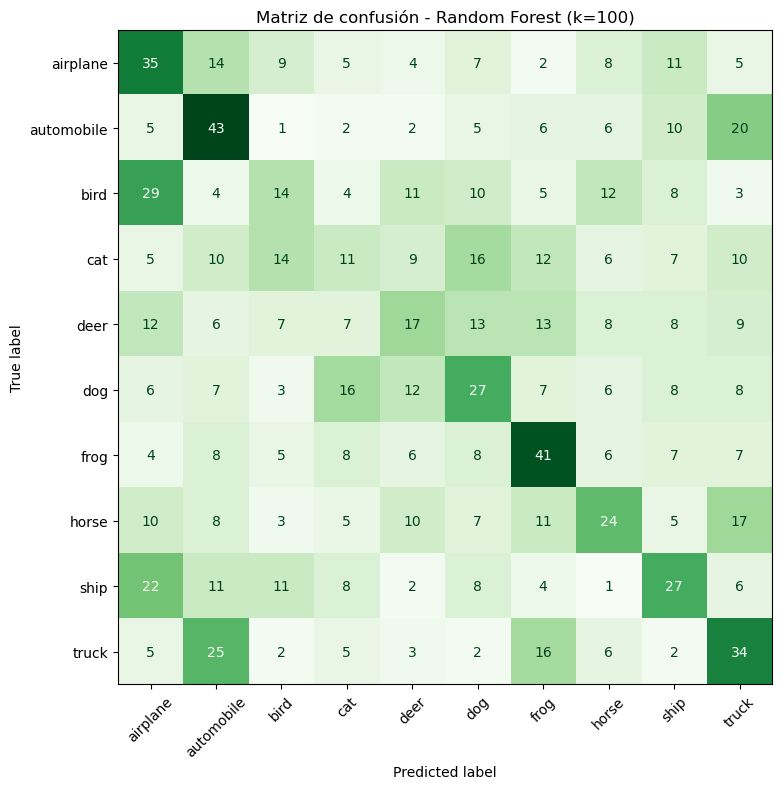

In [13]:
# Se usa k=100 (vocabulario base) para comparar directamente con SVM
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20]
}

rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_rf.fit(X_tr, y_tr)

y_pred_rf = grid_rf.best_estimator_.predict(X_te)
acc_rf = accuracy_score(y_te, y_pred_rf)

print(f"\nMejores hiperparámetros RF: {grid_rf.best_params_}")
print(f"Exactitud Random Forest (k={K_BASE}): {acc_rf:.4f} ({acc_rf*100:.2f}%)")
print(f"Exactitud SVM lineal    (k={K_BASE}): {acc_svm:.4f} ({acc_svm*100:.2f}%)")

# Matriz de confusión del RF
cm_rf = confusion_matrix(y_te, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=clases)
fig, ax = plt.subplots(figsize=(10, 8))
disp_rf.plot(ax=ax, cmap='Greens', colorbar=False, xticks_rotation=45)
ax.set_title(f'Matriz de confusión - Random Forest (k={K_BASE})')
plt.tight_layout()
plt.show()

#### 2c. Agregar validación cruzada con cinco particiones e informar medidas de tendencia central de la exactitud.

Validación cruzada 5-fold

SVM lineal (C=10, k=100):
Exactitudes por fold: [0.275 0.294 0.261 0.307 0.284]
Media: 0.2842
Mediana: 0.2840
Desv. estándar: 0.0157
Mín: 0.2610  |  Máx: 0.3070

Random Forest ({'max_depth': None, 'n_estimators': 200}, k=100):
Exactitudes por fold: [0.27  0.285 0.301 0.269 0.307]
Media: 0.2864
Mediana: 0.2850
Desv. estándar: 0.0156
Mín: 0.2690  |  Máx: 0.3070


/tmp/ipykernel_9818/4180733729.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([cv_svm, cv_rf], labels=['SVM lineal', 'Random Forest'], patch_artist=True,


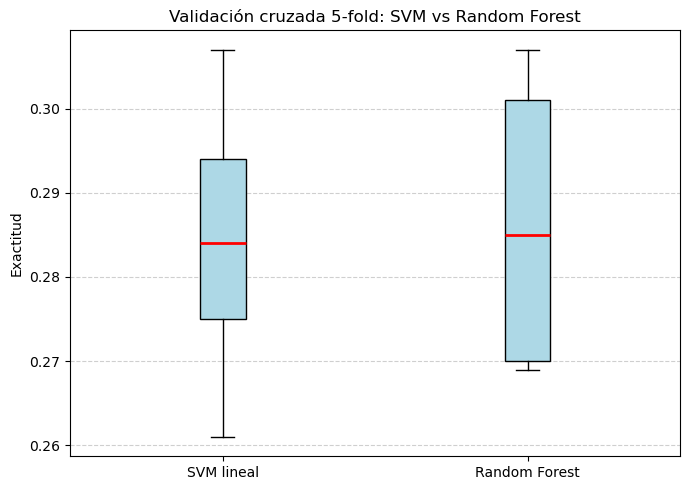

In [14]:
# Validación cruzada 5-fold para SVM y Random Forest
cv_svm = cross_val_score(
    SVC(kernel='linear', C=grid_svm.best_params_['C'], random_state=42),
    hists_10, labels_10, cv=5, scoring='accuracy', n_jobs=-1
)

cv_rf = cross_val_score(
    RandomForestClassifier(**grid_rf.best_params_, random_state=42),
    hists_10, labels_10, cv=5, scoring='accuracy', n_jobs=-1
)

print("Validación cruzada 5-fold")
print(f"\nSVM lineal (C={grid_svm.best_params_['C']}, k={K_BASE}):")
print(f"Exactitudes por fold: {cv_svm.round(4)}")
print(f"Media: {cv_svm.mean():.4f}")
print(f"Mediana: {np.median(cv_svm):.4f}")
print(f"Desv. estándar: {cv_svm.std():.4f}")
print(f"Mín: {cv_svm.min():.4f}  |  Máx: {cv_svm.max():.4f}")

print(f"\nRandom Forest ({grid_rf.best_params_}, k={K_BASE}):")
print(f"Exactitudes por fold: {cv_rf.round(4)}")
print(f"Media: {cv_rf.mean():.4f}")
print(f"Mediana: {np.median(cv_rf):.4f}")
print(f"Desv. estándar: {cv_rf.std():.4f}")
print(f"Mín: {cv_rf.min():.4f}  |  Máx: {cv_rf.max():.4f}")

# Visualización
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([cv_svm, cv_rf], labels=['SVM lineal', 'Random Forest'], patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Exactitud')
ax.set_title('Validación cruzada 5-fold: SVM vs Random Forest')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

---
### 3 Repetir el proceso con otra base de datos (opcional).

---
### 4. Preguntas

¿Por qué es necesario normalizar los histogramas?

**R.** La normalización de los histogramas es necesaria porque las imágenes pueden contener distinto número de descriptores SIFT: una imagen compleja y texturada producirá muchos más keypoints que una imagen simple. Sin normalizar, el histograma de una imagen con 1 000 descriptores tendría valores mucho más altos que uno con 100, aunque ambas muestren la misma distribución relativa de palabras visuales. Esto perjudicaría al clasificador, que interpretaría la magnitud absoluta en lugar del *patrón* de distribución. Al dividir entre la suma total (norma L1) o entre la norma euclidiana (L2), se elimina el efecto del tamaño de la imagen y se hace que los histogramas sean comparables entre sí, mejorando la generalización del clasificador.

¿Qué ocurre si $k$ es demasiado pequeño o si es demasiado grande?

**R.**

- **$k$ demasiado pequeño:** El vocabulario es poco expresivo. Muchos descriptores con apariencia distinta quedan asignados al mismo centroide (cuantización gruesa), por lo que los histogramas de clases diferentes se vuelven indistinguibles. El clasificador pierde capacidad discriminativa y la exactitud cae (subajuste del vocabulario).

- **$k$ demasiado grande:** El vocabulario es demasiado fino. Cada descriptor queda asignado a un centroide casi único, lo que produce histogramas muy dispersos y sensibles al ruido. Además, el costo computacional crece tanto en K-Means como en la asignación de palabras. Si $k$ supera el número promedio de descriptores por imagen, muchas entradas del histograma quedan en cero y el clasificador puede sobreajustarse a los datos de entrenamiento.

En la práctica se elige $k$ mediante validación cruzada, buscando el punto donde la exactitud se estabiliza antes de empezar a decrecer (curva en forma de codo o meseta).

¿Podría utilizarse este método para detección de objetos en lugar de clasificación?

**R.** El BoW estándar es inherentemente un modelo de *bolsa*: descarta la información espacial de los descriptores, resumiendo la imagen como un histograma de frecuencias sin importar dónde se encuentran las palabras visuales. Esto lo hace muy adecuado para **clasificación de escenas o categorías**, pero **insuficiente para detección de objetos**, donde la posición, la escala y la relación espacial entre partes del objeto son cruciales.

Sin embargo, existen extensiones que incorporan geometría:
- **Spatial Pyramid Matching (SPM):** divide la imagen en regiones y calcula un histograma por región, preservando información espacial aproximada.
- **Part-based models:** combinan BoW con modelos de partes deformables para localizar objetos.

En la práctica, la detección de objetos moderna se realiza con redes convolucionales (YOLO, Faster R-CNN, DETR), que aprenden representaciones espaciales y semánticas de manera conjunta, superando ampliamente a los métodos basados en BoW.